In [2]:
# This extension reloads all imports before running each cell
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from slam_project.mapping import mapper as mp
from slam_project.localization import odometry as od
from slam_project.models.occupancy_grid import occupancy_grid
from slam_project.io import load_data as ld

WORLD_BOUNDS = (-10, 10) # meters
SCALE = 0.1 # meters per box

GRID_DIM = int(np.abs(WORLD_BOUNDS[1] - WORLD_BOUNDS[0])/SCALE) # boxes along axis

X, Y, theta, t = od.parse_encoders('./data/train/Encoders20')
lidar = ld.get_lidar('./data/train/Hokuyo20')

ox, oy = mp.global_lidar2gridmap(lidar, X, Y, theta, t)

mp.global_lidar2gridmap_coords([lidar[0]], X, Y, theta, t)

grid = occupancy_grid(0, 0, SCALE, WORLD_BOUNDS)

grid.add_scan_hits()

grid.plot()




IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

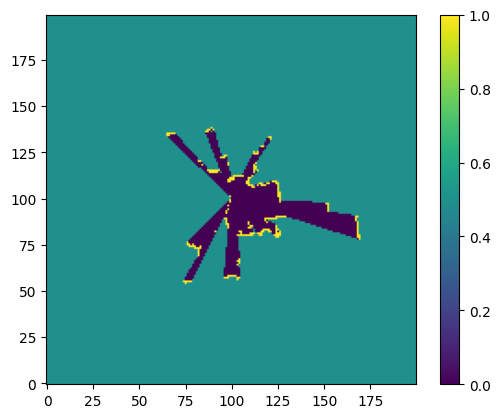

In [4]:
from slam_project.mapping import mapper as mp
from slam_project.localization import odometry as od
from slam_project.models.occupancy_grid import occupancy_grid
from slam_project.io import load_data as ld
import matplotlib.pyplot as plt
from slam_project.visualization import animations as anim

WORLD_BOUNDS = (-10, 10)  # meters
SCALE = 0.1  # meters per box
SCAN_IDX = 0

X, Y, theta, t = od.parse_encoders('./data/train/Encoders20')
lidar = ld.get_lidar('./data/train/Hokuyo20')

grid = occupancy_grid(0, 0, SCALE, WORLD_BOUNDS)

i = mp.nearest_pose_index(lidar[0]['t'], t)

ox, oy = mp.lidar_hits_global(lidar[0], X[i], Y[i], theta[i])

grid.add_scan_hits(ox, oy, X[i], Y[i], runBresenham=True)

grid.plot()